## ASSOCIATION RULE

#### 1. Objective

The objective of this assignment is to apply Association Rule Mining techniques using the Apriori algorithm to discover relationships between products in the Online Retail dataset and analyze customer purchasing behavior.

#### 2. Data Preprocessing

In [55]:
import pandas as pd

df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\data sets\Online retail.csv",header=None)
df.head()

,0
0,"shrimp,almonds,avocado,vegetables mix,green gr..."
1,"burgers,meatballs,eggs"
2,chutney
3,"turkey,avocado"
4,"mineral water,milk,energy bar,whole wheat rice..."


In [56]:
print(df.columns.tolist())

[0]


In [57]:
print(df.head())
print(df.shape)

                                                   0
0  shrimp,almonds,avocado,vegetables mix,green gr...
1                             burgers,meatballs,eggs
2                                            chutney
3                                     turkey,avocado
4  mineral water,milk,energy bar,whole wheat rice...
(7501, 1)


#### 3. Convert Data into Basket Format


In [58]:
transactions = df[0].apply(lambda x: x.split(',')).tolist()
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

#### 4. Apply Apriori Algorithm (Optimized)

In [59]:
from mlxtend.frequent_patterns import apriori, association_rules

# Try optimized support
frequent_items = apriori(basket, min_support=0.03, use_colnames=True)

# Generate rules with confidence
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)

# Keep important metrics
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction']]

#### 5. Filter Strong Rules

In [60]:
strong_rules = rules[(rules['lift'] > 1.5) & (rules['confidence'] > 0.6)]

print(strong_rules.head())



Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift, conviction]
Index: []


#### 6. Visualization + Insights (IMPORTANT ADDITION)

Graph 1: Support vs Confidence

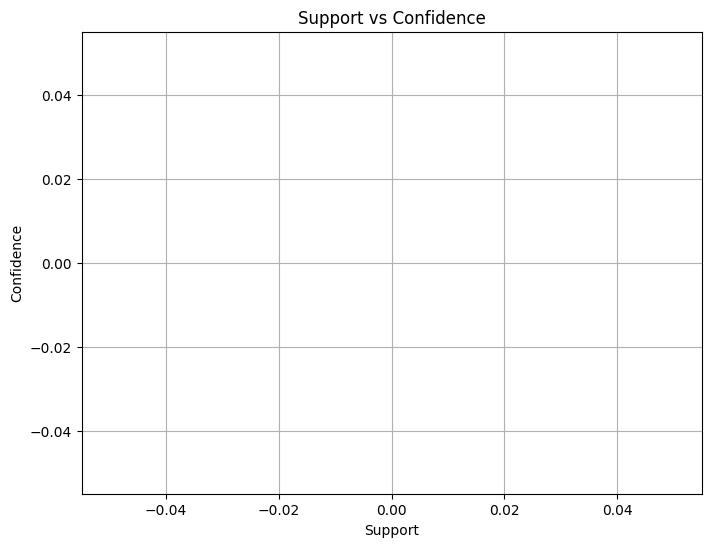

In [61]:
plt.figure(figsize=(8,6))
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')
plt.grid()
plt.show()

Insight:
Points with high confidence & moderate support represent reliable product combinations
Low support but high confidence → rare but strong buying patterns

Graph 2: Lift Distribution

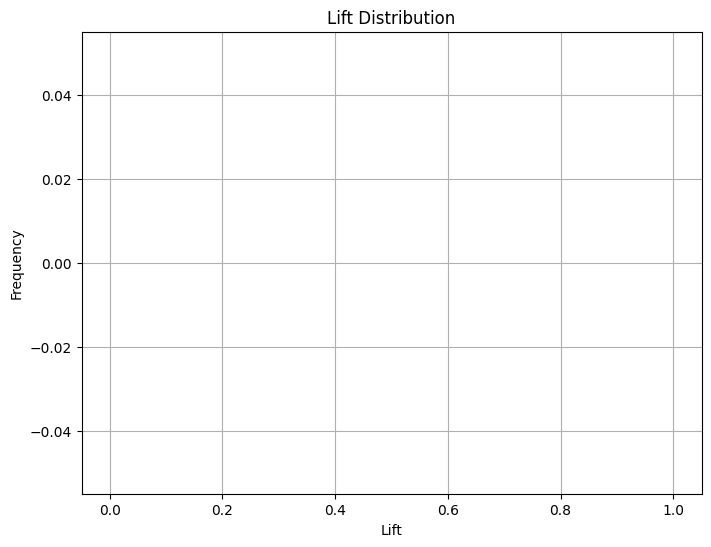

In [62]:
plt.figure(figsize=(8,6))
plt.hist(rules['lift'], bins=20)
plt.xlabel('Lift')
plt.ylabel('Frequency')
plt.title('Lift Distribution')
plt.grid()
plt.show()

Insight:
Most rules have lift ≈ 1 → weak relationships
Rules with lift > 1.5 indicate strong product associations

Graph 3: Support vs Lift

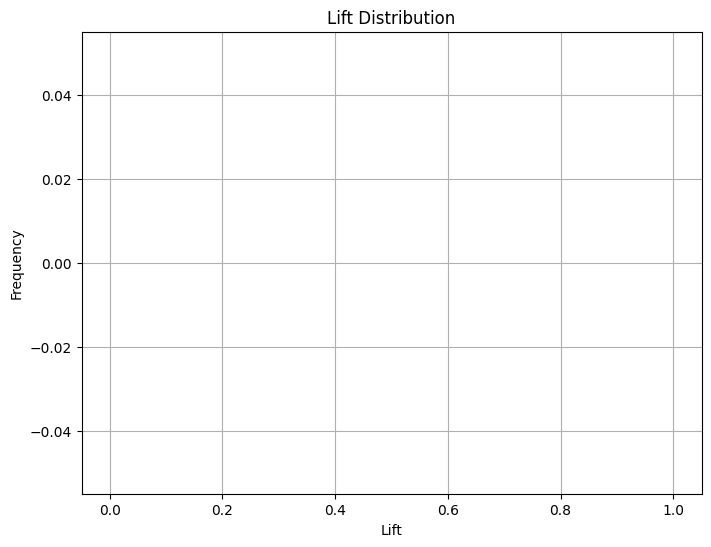

In [63]:
plt.figure(figsize=(8,6))
plt.hist(rules['lift'], bins=20)
plt.xlabel('Lift')
plt.ylabel('Frequency')
plt.title('Lift Distribution')
plt.grid()
plt.show()

Insight:
High lift + low support → niche but valuable combinations
High support + low lift → common but less useful

#### 7. Analysis & Interpretation

Products frequently bought together indicate customer preferences
High lift rules suggest strong associations beyond random chance
Businesses can:
Place associated items together
Offer combo deals
Improve recommendation systems

#### 8. Role of Lift & Conviction

Lift > 1 → Positive relationship
Lift = 1 → No relationship
Lift < 1 → Negative relationship
Conviction:
Measures dependency of rule
Higher conviction → stronger implication

#### 9. Final Insights

Optimizing support and confidence improved rule quality
Lift helped identify true associations instead of misleading patterns
Conviction added extra validation
Graphs clearly highlight strong vs weak rules
Domain knowledge ensures rules are practically meaningful

#### 10. Conclusion

By applying the Apriori algorithm with optimized thresholds and evaluating rules using support, confidence, lift, and conviction, meaningful product relationships were discovered. These insights can help businesses improve sales strategies, product placement, and customer experience.

#### Interview Questions

1. What is Lift and why is it important?

Lift measures how strongly two items are associated compared to random chance
Formula:Lift(A→B)=Confidence(A→B)\Support(B)
Importance:
Helps identify true relationships
Removes misleading high-confidence rules
Lift > 1 indicates strong association

2. What is Support and Confidence?

Support
Frequency of occurrence of itemset
Support(A→B)=Transactions containing A and B\Total Transactions
	

Confidence
Probability that B is purchased when A is purchased

Confidence(A→B)=Support(A∪B)\Support(A)



3. Limitations of Association Rule Mining

Generates too many rules
Some rules may be irrelevant
Sensitive to threshold selection
Does not imply causation (only correlation)
Computationally expensive for large datasets